# Keeping Notebooks Small with Static Images

By default, every `unichart` plot is an **interactive Plotly figure** — zoom, pan,
hover. The catch: Plotly stores **every data point as JSON** in the notebook's
output. For a handful of points that's nothing, but for a dense scatter of tens or
hundreds of thousands of points it makes the saved `.ipynb` balloon (and bloats
git diffs).

`nb.set_static_images()` switches plotting methods to return a **flat inline PNG**
instead. A PNG's size depends on its pixels, **not** on how many points it draws —
so for data-heavy plots it stays roughly constant while the interactive JSON keeps
growing. You trade interactivity for a much smaller file.

| | Interactive (default) | Static images |
|---|---|---|
| Return type | Plotly `Figure` | `IPython.display.Image` (PNG) |
| Output stored in `.ipynb` | every point, as JSON (grows with N) | PNG bytes (≈ constant in N) |
| Interactivity | zoom / pan / hover | none (flat picture) |
| `nb.last_fig` | real `Figure` | **still** the real `Figure` |
| `nb.save_png()` | works | works |

> **When it helps:** big, point-dense plots. For small plots the interactive JSON
> is already tiny — a PNG can be *larger*, so leave static off. There's a crossover
> (shown below) that depends on point count vs. image size.
>
> `last_fig` always caches the real figure, so `save_png()` and re-styling keep
> working either way. Requires `kaleido`; if it's missing, plots fall back to
> interactive automatically.

## Setup — imports and sample data

A small dataset to show the interactive default, and a large one (150k points) to show where static images pay off.

In [1]:
# --- make repo-root importable (notebook lives in demo_notebooks/) ---
import sys, os
_repo_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

import numpy as np
import pandas as pd
import unichart

rng = np.random.default_rng(7)

def make_data(n):
    "n points across two runs: an RPM sweep vs a noisy Temp channel."
    return pd.DataFrame({
        "RUN":  np.where(np.arange(n) % 2 == 0, "Run A", "Run B"),
        "RPM":  rng.uniform(1500, 9500, n),
        "Temp": 300 + rng.uniform(1500, 9500, n) / 14 + rng.normal(0, 30, n),
    })

df_small = make_data(180)        # for the interactive demo
df_big   = make_data(150_000)    # for the file-size story
df_small.head()

,RUN,RPM,Temp
0,Run A,6500.763733,922.900578
1,Run B,8677.710408,871.883092
2,Run A,7705.485522,917.582962
3,Run B,3301.657520,697.210594
4,Run A,3901.330279,929.157888


## 1. The default — an interactive figure

Plotting returns a Plotly `Figure` that renders interactively. With small data this
is exactly what you want.

In [2]:
nb = unichart.UnichartNotebook()
nb.load_df(df_small, set_name_column="RUN", set_idx_column="RUN")
nb.suptitle = "Interactive (default) — 180 points"

fig = nb.plot(x="RPM", y="Temp")
print("return type:", type(fig).__name__)
fig

UniChart Notebook Environment Initialized.
Loaded Set 0: Run A
Loaded Set 1: Run B
return type: Figure


## 2. The problem: interactive output grows with point count

Interactive figures embed every point as JSON. Here's how big that stored output
gets for the **150k-point** plot — we measure it without rendering it interactively
(displaying it would add several MB to *this* notebook, which is the very thing
we're trying to avoid).

In [3]:
nb_big = unichart.UnichartNotebook()
nb_big.load_df(df_big, set_name_column="RUN", set_idx_column="RUN")
nb_big.suptitle = "150,000 points"

big_fig = nb_big.plot(x="RPM", y="Temp")          # a Figure (static mode still off)
interactive_bytes = len(big_fig.to_json())
print(f"Interactive output for 150k points: {interactive_bytes:,} bytes of JSON")

UniChart Notebook Environment Initialized.
Loaded Set 0: Run A
Loaded Set 1: Run B
Interactive output for 150k points: 3,394,778 bytes of JSON


## 3. Turn on static images

One call flips the switch. The *same* plotting call now returns a flat PNG whose
size is driven by pixels, not point count — far smaller for this dense plot.

Static images on (scale=2).


return type : Image
Static PNG  : 963,270 bytes
Smaller by  : 3.5x


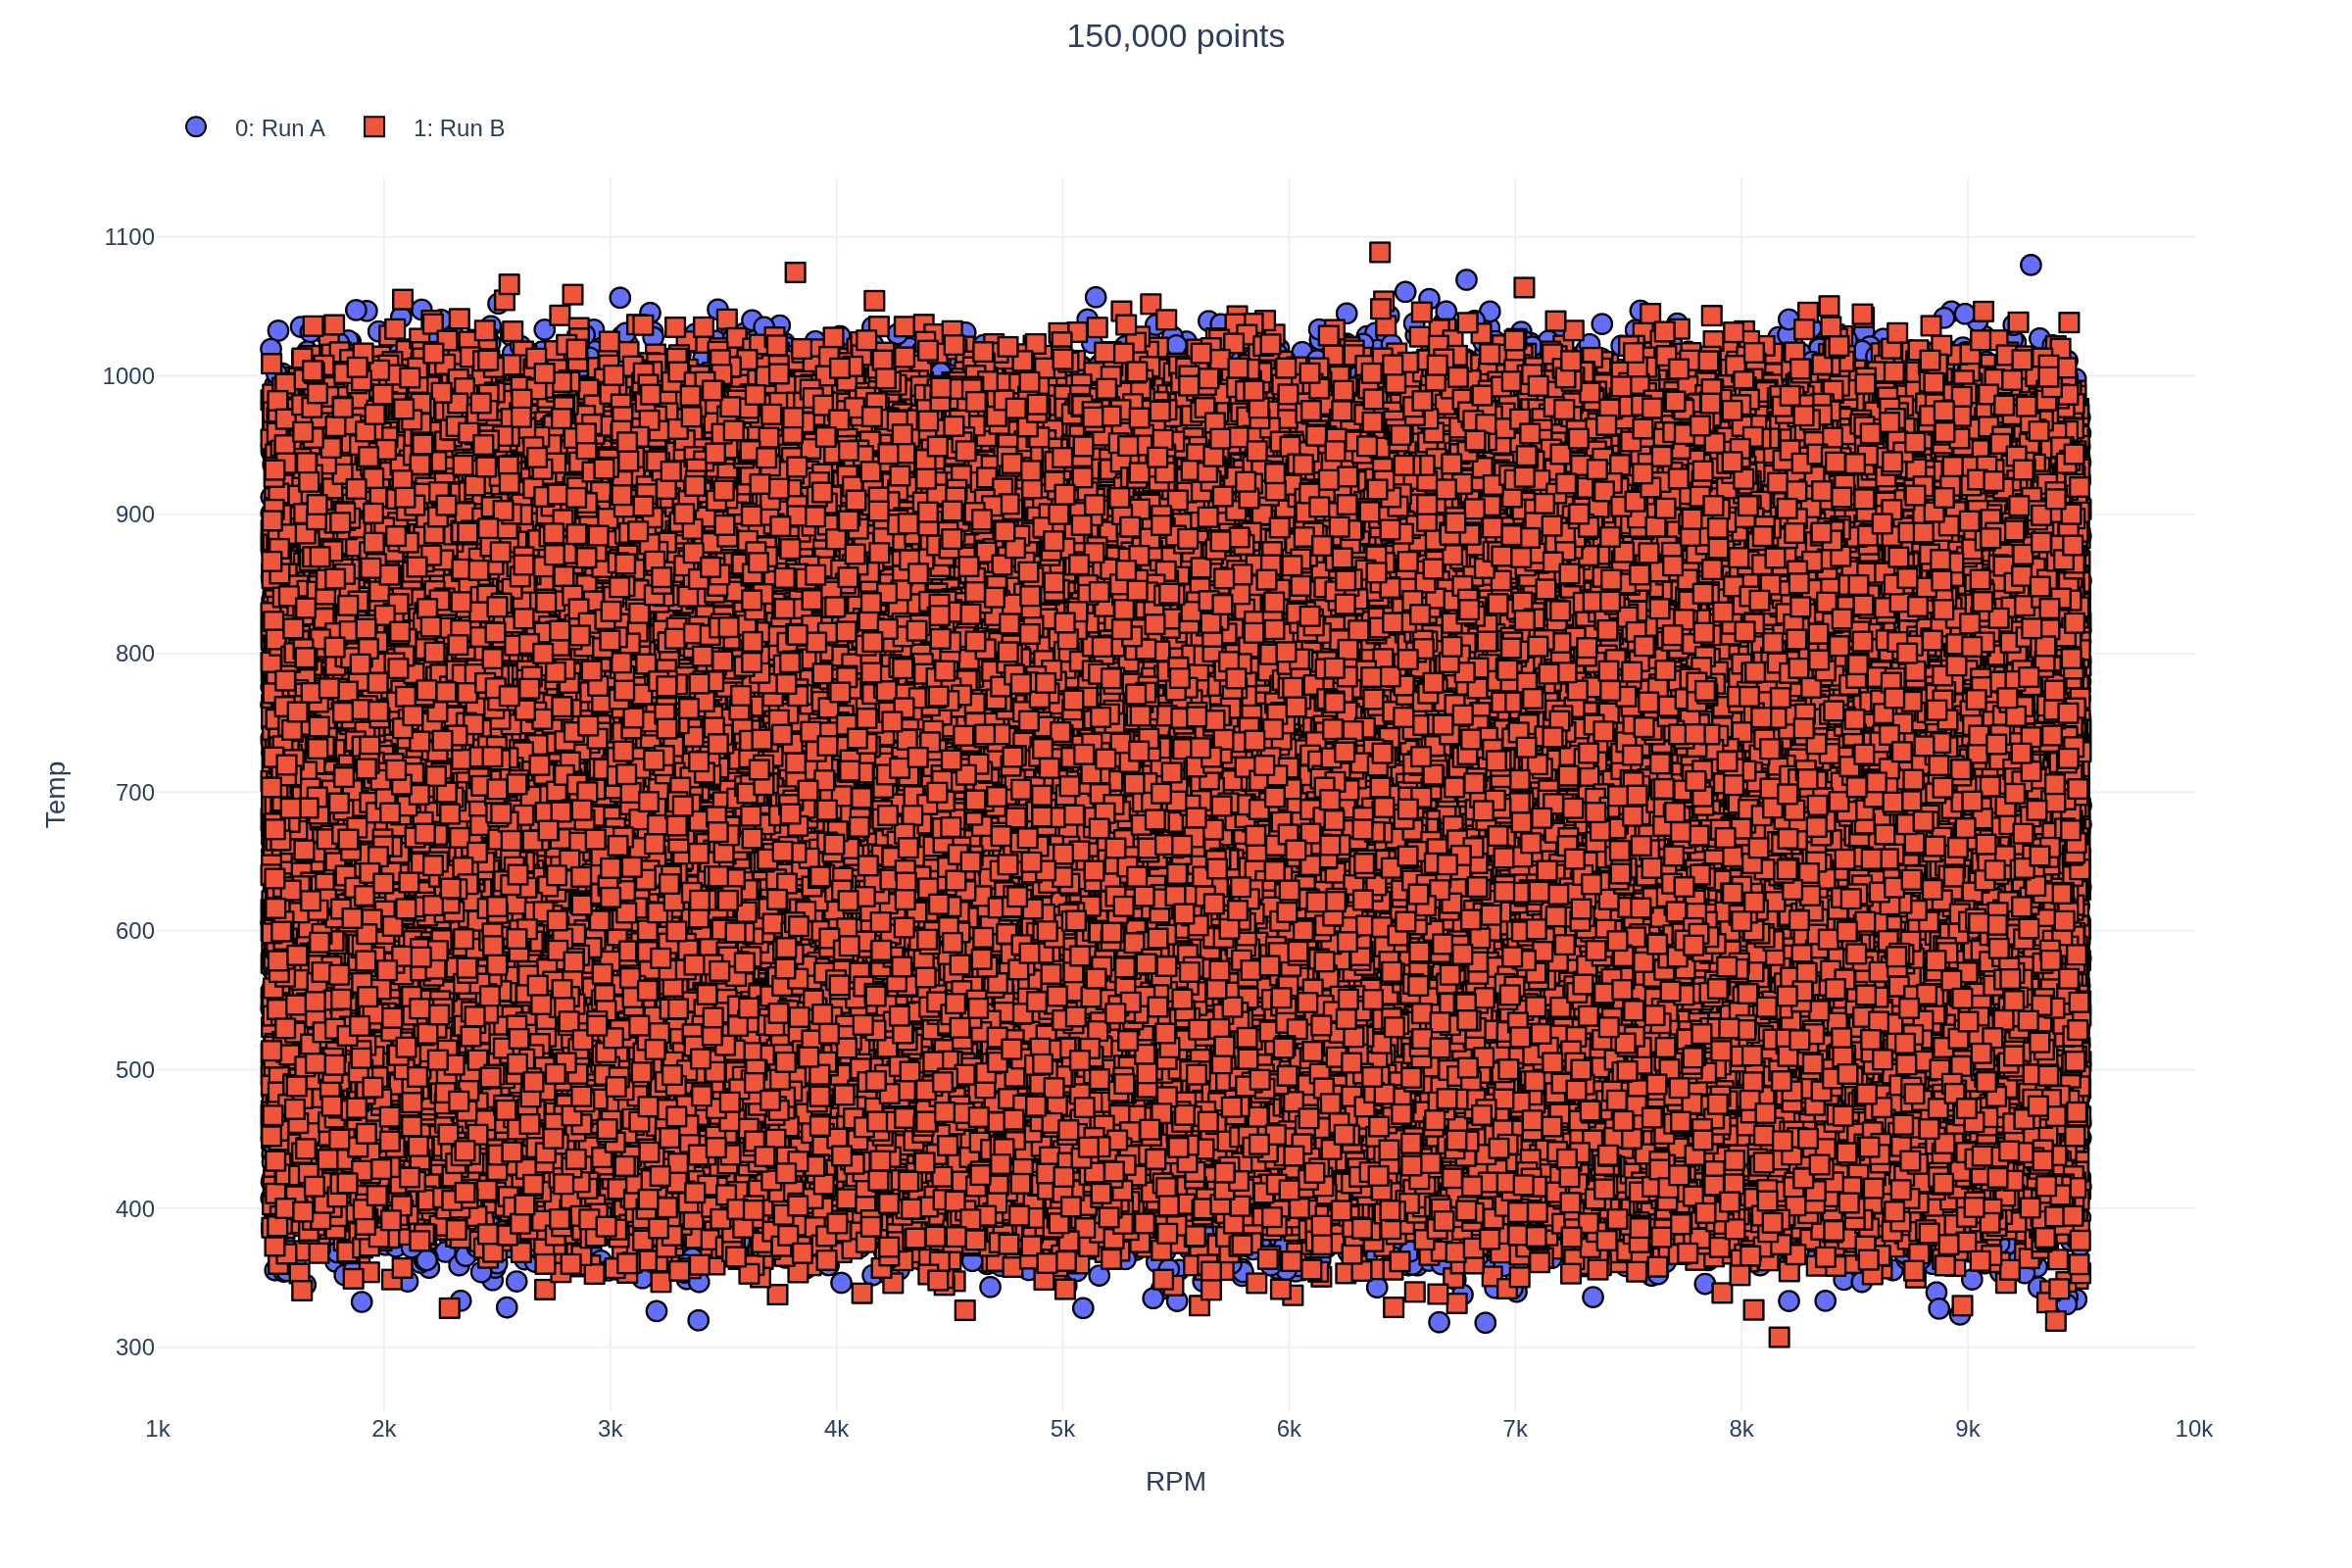

In [4]:
nb_big.set_static_images()                        # on
img = nb_big.plot(x="RPM", y="Temp")
static_bytes = len(img.data)
print("return type :", type(img).__name__)
print(f"Static PNG  : {static_bytes:,} bytes")
print(f"Smaller by  : {interactive_bytes / static_bytes:.1f}x")
img

## 4. Where the crossover is

PNG size barely moves with more points; interactive JSON scales linearly with them.
Below a certain count interactive is actually *smaller* — so static images are a win
specifically for data-heavy plots. (The exact crossover depends on this config:
PNG `scale=2`, a 1200×800 figure, and a dense scatter. More pixels or denser ink
push it higher; fewer push it lower.)

In [5]:
rows = []
for n in [200, 5_000, 50_000, 150_000]:
    d = make_data(n)
    t = unichart.UnichartNotebook(); t.load_df(d, set_name_column="RUN", set_idx_column="RUN")
    j = len(t.plot(x="RPM", y="Temp").to_json())          # interactive JSON
    t.set_static_images()
    p = len(t.plot(x="RPM", y="Temp").data)               # static PNG
    rows.append((n, j, p, "static" if p < j else "interactive"))

print(f"{'points':>8} {'interactive JSON':>18} {'static PNG':>12}   smaller")
print("-" * 52)
for n, j, p, win in rows:
    print(f"{n:>8,} {j:>18,} {p:>12,}   {win}")

UniChart Notebook Environment Initialized.
Loaded Set 0: Run A
Loaded Set 1: Run B
Static images on (scale=2).


UniChart Notebook Environment Initialized.
Loaded Set 0: Run A
Loaded Set 1: Run B
Static images on (scale=2).


UniChart Notebook Environment Initialized.
Loaded Set 0: Run A
Loaded Set 1: Run B
Static images on (scale=2).


UniChart Notebook Environment Initialized.
Loaded Set 0: Run A
Loaded Set 1: Run B
Static images on (scale=2).


  points   interactive JSON   static PNG   smaller
----------------------------------------------------
     200             12,782      224,574   interactive
   5,000            121,407    1,177,377   interactive
  50,000          1,137,301      973,417   static
 150,000          3,394,859      983,122   static


## 5. `last_fig` is preserved — `save_png()` still works

Even in static mode the real `Figure` is cached on `nb.last_fig`, so anything that
operates on the figure object keeps working — including saving a high-res PNG to
disk.

In [6]:
print("last_fig type:", type(nb_big.last_fig).__name__)

nb_big.save_png("static_demo_plot.png", scale=2)
print("file on disk :", os.path.getsize("static_demo_plot.png"), "bytes")
os.remove("static_demo_plot.png")   # cleanup

last_fig type: Figure


Plot saved to static_demo_plot.png
file on disk : 963270 bytes


## 6. Control resolution with `scale`

`scale` is the PNG resolution multiplier (default `2`). Raise it for crisper images,
drop it to `1` for the smallest files. (Shown on the small dataset to keep this
notebook lean.)

In [7]:
nb.set_static_images(scale=1)
print("scale=1 PNG bytes:", len(nb.plot(x="RPM", y="Temp").data))
nb.set_static_images(scale=3)
print("scale=3 PNG bytes:", len(nb.plot(x="RPM", y="Temp").data))

Static images on (scale=1).


scale=1 PNG bytes: 83333
Static images on (scale=3).


scale=3 PNG bytes: 385482


## 7. Turn it back off

Pass `False` to return to interactive figures at any time.

In [8]:
nb.set_static_images(False)
nb.suptitle = "Interactive again"
back = nb.plot(x="RPM", y="Temp")
print("return type:", type(back).__name__)
back

Static images off (scale=3).
return type: Figure


## Things to remember

- **Use it for data-heavy plots.** That's where interactive JSON gets big and a
  PNG stays small. For light plots, interactive is already tiny — leave static off.
- **The return value changes.** With static mode on, plot methods return an
  `Image`, not a `Figure`, so you can't chain `.update_layout(...)` on the result —
  use `nb.last_fig` for that.
- **`save_png` / `last_fig` are unaffected** — they always use the real figure.
- **Needs `kaleido`.** If it isn't installed, plots warn once and fall back to
  interactive rather than failing.